In [1]:
import torch
import os
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import VGG19_Weights
import matplotlib.pyplot as plt
from torchvision.utils import save_image
import random

In [2]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")

device

device(type='cuda')

In [3]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
style_img_dir = '/content/drive/MyDrive/pbn'
contnet_img_dir = '/content/drive/MyDrive/imagenet'

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/imagenet/content -d /content
!unzip /content/drive/MyDrive/pbn/train_1.zip -d /content/style
!unzip /content/drive/MyDrive/pbn/train_2.zip -d /content/style
!unzip /content/drive/MyDrive/pbn/train_3.zip -d /content/style

In [5]:
!mv /content/style/train_1/* /content/style/ && rm -r /content/style/train_1
!mv /content/style/train_2/* /content/style/ && rm -r /content/style/train_2
!mv /content/style/train_3/* /content/style/ && rm -r /content/style/train_3

In [3]:
#проверка файла на краш
def is_valid_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()  # Verify file integrity
        return True
    except (IOError, SyntaxError):
        return False

In [4]:
import os
from PIL import Image

def check_and_remove_corrupted_images(folder_path):
    # Get a list of all files in the folder
    files = os.listdir(folder_path)

    # Iterate through each file
    for file in files:
        file_path = os.path.join(folder_path, file)

        # Check if the file is a directory
        if os.path.isdir(file_path):
            continue

        # Attempt to open the image file
        try:
            with Image.open(file_path) as img:
                img.verify()  # Verify if the file is readable
        except Exception as e:
            print(f"Corrupted image found: {file_path}, Error: {e}")

            # If the file is corrupted, delete it
            os.remove(file_path)
            print(f"Corrupted image deleted: {file_path}")

# Example usage
content_images_path = "/content/content/train"
style_images_path = "/content/style"
check_and_remove_corrupted_images(content_images_path)
check_and_remove_corrupted_images(style_images_path)


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3167: DecompressionBombWarning: Image size (129097476 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3167: DecompressionBombWarning: Image size (94435468 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3167: DecompressionBombWarning: Image size (131790400 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3167: DecompressionBombWarning: Image size (107327830 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [5]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset

class StyleTransferDataset(Dataset):
    def __init__(self, content_dir, style_dir, transform=None):
        self.content_dir = content_dir
        self.style_dir = style_dir
        self.content_images = []
        self.style_images = []
        self.transform = transform
        self.max_retries = 5

        # Load content images
        for filename in os.listdir(self.content_dir):
            if filename.endswith('.jpg'):
                file_path = os.path.join(self.content_dir, filename)
                if self.is_valid_image(file_path):
                    self.content_images.append(filename)
                else:
                    print(f"Corrupted content image: {file_path}")

        # Load style images
        for filename in os.listdir(self.style_dir):
            if filename.endswith('.jpg'):
                file_path = os.path.join(self.style_dir, filename)
                if self.is_valid_image(file_path):
                    self.style_images.append(filename)
                else:
                    print(f"Corrupted style image: {file_path}")

    def __len__(self):
        return min(len(self.content_images), len(self.style_images))

    def __getitem__(self, idx):
        retries = 0
        while retries < self.max_retries:
            content_img_name = self.content_images[idx]
            style_img_name = random.choice(self.style_images)

            content_img_path = os.path.join(self.content_dir, content_img_name)
            style_img_path = os.path.join(self.style_dir, style_img_name)

            try:
                content_img = Image.open(content_img_path).convert('RGB')
                style_img = Image.open(style_img_path).convert('RGB')
                break  # Break out of the loop if images are loaded successfully
            except Exception as e:
                print(f"Error opening image file: {e}")
                print(f"Problematic content image path: {content_img_path}")
                print(f"Problematic style image path: {style_img_path}")
                retries += 1

        if retries == self.max_retries:
            # If max retries reached, return None to indicate failure
            return None

        if self.transform:
            content_img = self.transform(content_img)
            style_img = self.transform(style_img)

        return content_img.to(device), style_img.to(device)

    @staticmethod
    def is_valid_image(file_path):
        try:
            with Image.open(file_path) as img:
                img.verify()  # Verify if the file is readable
            return True
        except Exception as e:
            print(f"Invalid image file: {file_path}, error: {e}")
            return False

# Example usage:
# dataset = StyleTransferDataset(content_dir, style_dir, transform)
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [6]:
transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]
)
content_dir = '/content/content/train'
style_dir = '/content/style'

dataset = StyleTransferDataset(content_dir, style_dir, transform=transform)

In [7]:
len(dataset)

2009

In [8]:
from torch.utils.data import DataLoader


train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

In [9]:
len(train_loader)

2009

In [10]:
# directory = '/content/generated'
dir = '/content/drive/MyDrive/generated'


In [11]:
def load_images(loader, path):
  img = Image.open(path)
  img = loader(img).unsqueeze(0)
  return img.to(device)

In [12]:
gen_image_creds = ("origin.jpg", "gen_img.png")

gen_image = Image.open(os.path.join(dir, gen_image_creds[0]))
gen_image.save(os.path.join(dir, gen_image_creds[1]))
gen_image_name = "gen_img.png"
gen_img = load_images(transform, os.path.join(dir, gen_image_creds[1]))
gen_img.requires_grad = True

In [13]:
learning_rate = 0.001
li = [0, 5, 10, 19, 28]
optimizer = optim.Adam([gen_img], lr=learning_rate)
min_loss = 10e8
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
class VGG19(nn.Module):

    def __init__(self):
        super(VGG19, self).__init__()  # Call constructor of base class
        self.select_features = ['0', '5', '10', '19', '28'] #conv layers
        self.model = models.vgg19(weights=VGG19_Weights.DEFAULT).features

    def forward(self, x):
        x = x.to(device)
        features = []       # features of required layers
        for name, layer in self.model._modules.items():
            x = layer(x)
            if name in self.select_features:
                features.append(x)
        return features

In [15]:
# content loss
def content_loss(content_img, target_img):
    return torch.mean((target_img - content_img)**2)

# Gram Matrix calc
def gram_matrix(input, c, h, w):
    # c-channels, h-heightm w-weight
    input = input.view(c, h*w)
    return torch.mm(input, input.t())

def style_loss(target_img, style_img):
    _, c, h, w = target_img.size()
    G = gram_matrix(target_img, c, h, w) # Gram matrix for target img
    S = gram_matrix(style_img, c, h, w) # Gram matrxi for style img
    return torch.mean((G - S)**2) / (c * h * w)

In [16]:
model = VGG19()
model = model.to(device)
model.eval()
n_steps = 20

In [17]:
# !pip install --upgrade Pillow

In [ ]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
alpha = 0.0001
beta = 0.01

content_losses = []
style_losses = []
total_losses = []
for epoch in range(n_steps):
    for content_img, style_img in tqdm(train_loader):
        if content_img is None or style_img is None:
            continue  # Skip None values
        content_img = content_img.to(device)
        style_img = style_img.to(device)
        content_features = model(content_img)
        style_features = model(style_img)
        gen_features = model(gen_img)

        optimizer.zero_grad()
        content_loss_ = 0
        style_loss_ = 0

        for layer_content, layer_style, layer_gen in zip(content_features, style_features, gen_features):
            content_loss_ += content_loss(layer_content, layer_gen)
            style_loss_ += style_loss(layer_gen, layer_style)

        content_losses.append(content_loss_)
        style_losses.append(style_loss_)

        loss = alpha * content_loss_ + beta * style_loss_
        del content_loss_
        del style_loss_

        if loss < min_loss:
            min_loss = loss
            save_image(gen_img[0], os.path.join(dir, "best.png"))
        loss.backward()
        optimizer.step()

        total_losses.append(loss)

        del loss



    print(f"Loss at epoch {epoch+1}, content_loss: {content_losses[len(content_losses) - 1]}, style_loss: {style_losses[len(style_losses) - 1]},  total: {total_losses[len(total_losses) - 1]}")


    if (epoch + 1) % 2 == 0:
        save_image(gen_img[0],  os.path.join(dir, "", "gen_img"+str(epoch+1)+".png"))



In [ ]:
import matplotlib.pyplot as plt




# Sort the losses arrays
content_losses_sorted = sorted(content_losses)
style_losses_sorted = sorted(style_losses)
total_losses_sorted = sorted(total_losses)


In [ ]:

# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(content_losses_sorted) + 1), content_losses_sorted, label='Content Loss', color='blue')
plt.plot(range(1, len(style_losses_sorted) + 1), style_losses_sorted, label='Style Loss', color='red')
plt.plot(range(1, len(total_losses_sorted) + 1), total_losses_sorted, label='Total Loss', color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses over Epochs')
plt.legend()
plt.grid(True)
plt.show()

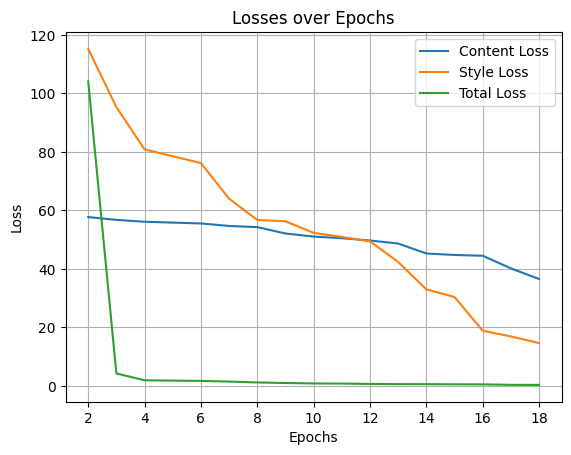

In [10]:
import matplotlib.pyplot as plt


# Plot the losses
plt.plot(epochs, content_losses, label='Content Loss')
plt.plot(epochs, style_losses, label='Style Loss')
plt.plot(epochs, total_losses, label='Total Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses over Epochs')
plt.legend()
plt.grid(True)
plt.show()


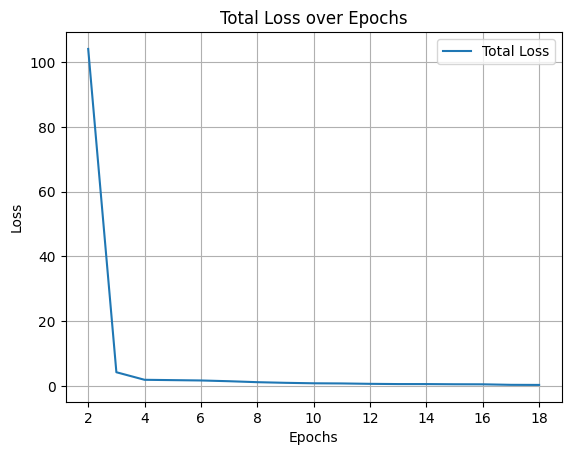

In [11]:
# Plot the losses
plt.plot(epochs, total_losses, label='Total Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Total Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()